In [1]:
%pip install opencv-python
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline
from IPython.display import Image

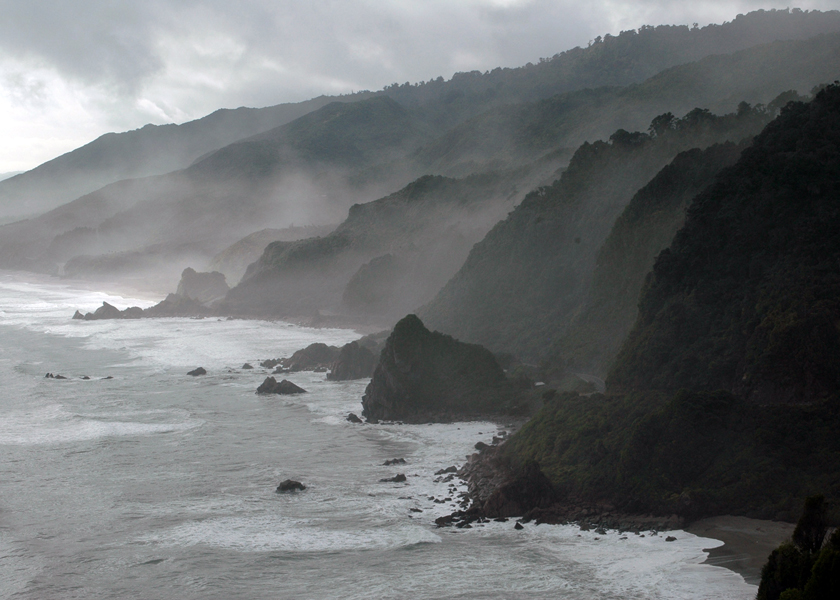

In [4]:
img_bgr = cv2.imread("assets/New_Zealand_Coast.jpg", cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Mostrando a imagem 18x18
Image(filename="assets/New_Zealand_Coast.jpg")

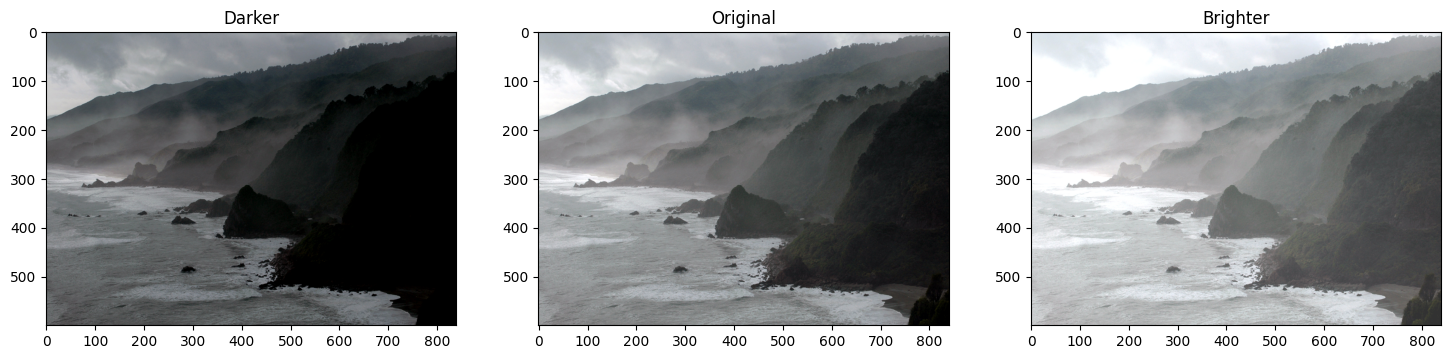

In [5]:
matrix = np.ones(img_rgb.shape, dtype=np.uint8) * 50

img_rgb_brighter = cv2.add(img_rgb, matrix)
img_rgb_darker = cv2.subtract(img_rgb, matrix)

# Mostrando as imagens
plt.figure(figsize=(18, 5))
plt.subplot(131); plt.imshow(img_rgb_darker); plt.title("Darker");
plt.subplot(132); plt.imshow(img_rgb); plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter); plt.title("Brighter");

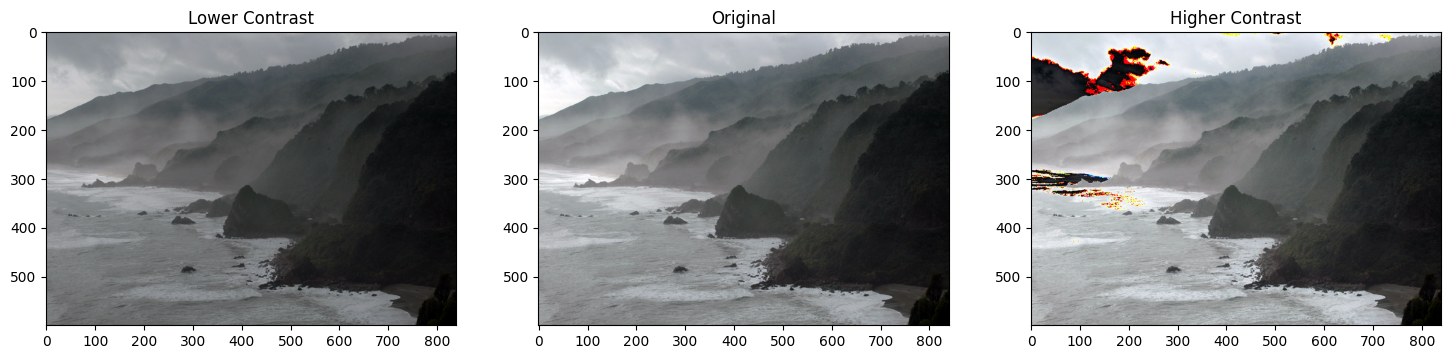

In [6]:
matrix1 = np.ones(img_rgb.shape) * .8
matrix2 = np.ones(img_rgb.shape) * 1.2

img_rgb_darker = np.uint8(cv2.multiply(np.float64(img_rgb), matrix1))
img_rgb_brighter = np.uint8(cv2.multiply(np.float64(img_rgb), matrix2))

# Mostrando as imagens
plt.figure(figsize=(18, 5))
plt.subplot(131); plt.imshow(img_rgb_darker); plt.title("Lower Contrast");
plt.subplot(132); plt.imshow(img_rgb); plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter); plt.title("Higher Contrast");

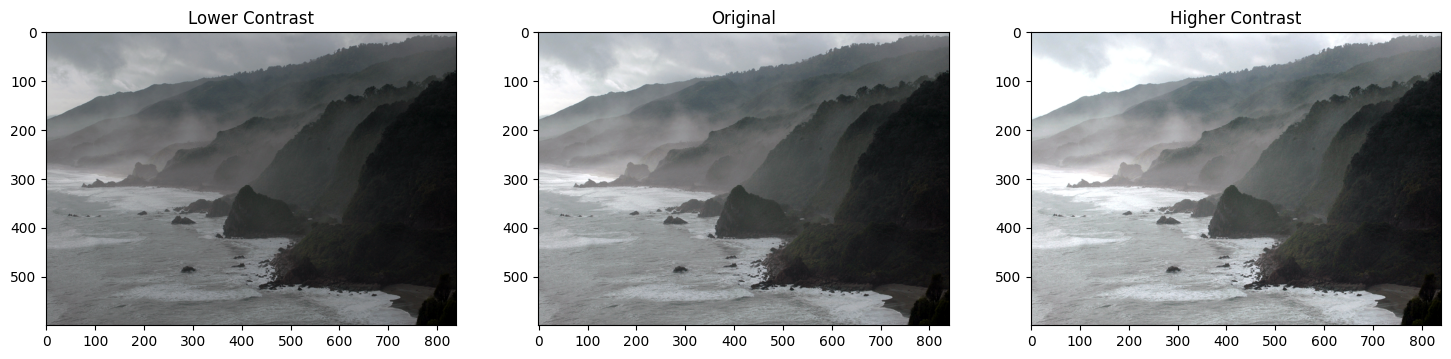

In [7]:
matrix1 = np.ones(img_rgb.shape) * .8
matrix2 = np.ones(img_rgb.shape) * 1.2

img_rgb_darker = np.uint8(cv2.multiply(np.float64(img_rgb), matrix1))
img_rgb_brighter = np.uint8(np.clip(cv2.multiply(np.float64(img_rgb), matrix2), 0, 255))

# Mostrando as imagens
plt.figure(figsize=(18, 5))
plt.subplot(131); plt.imshow(img_rgb_darker); plt.title("Lower Contrast");
plt.subplot(132); plt.imshow(img_rgb); plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter); plt.title("Higher Contrast");

(572, 800)


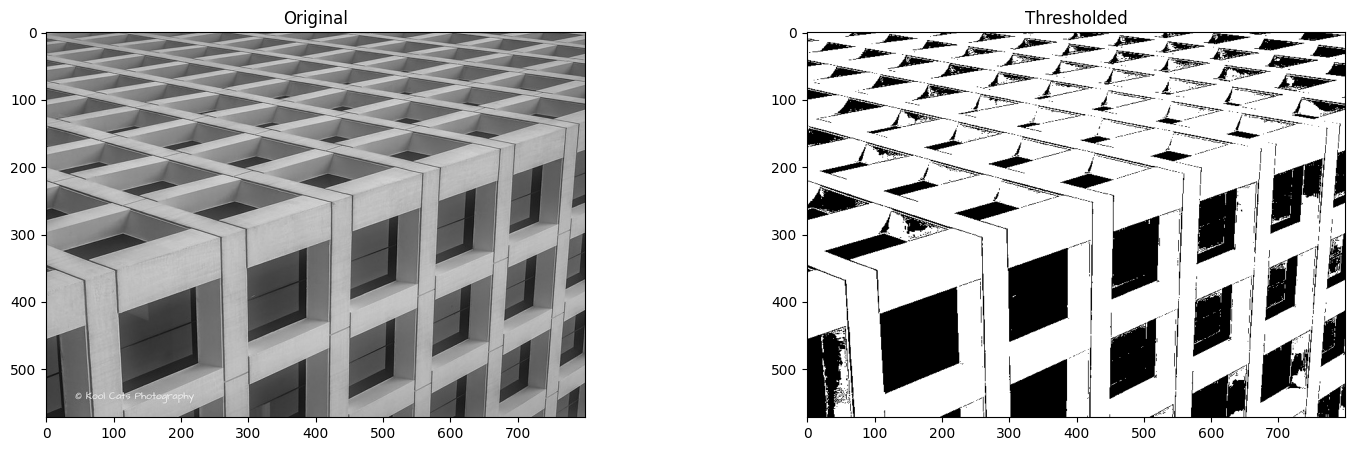

In [12]:
img_read = cv2.imread("assets/building-windows.jpg", cv2.IMREAD_GRAYSCALE)
retval, img_thresh = cv2.threshold(img_read, 100, 255, cv2.THRESH_BINARY)

# Mostrando as imagens
plt.figure(figsize=[18, 5])
plt.subplot(121); plt.imshow(img_read, cmap="gray"); plt.title("Original");
plt.subplot(122); plt.imshow(img_thresh, cmap="gray"); plt.title("Thresholded");

print(img_thresh.shape)

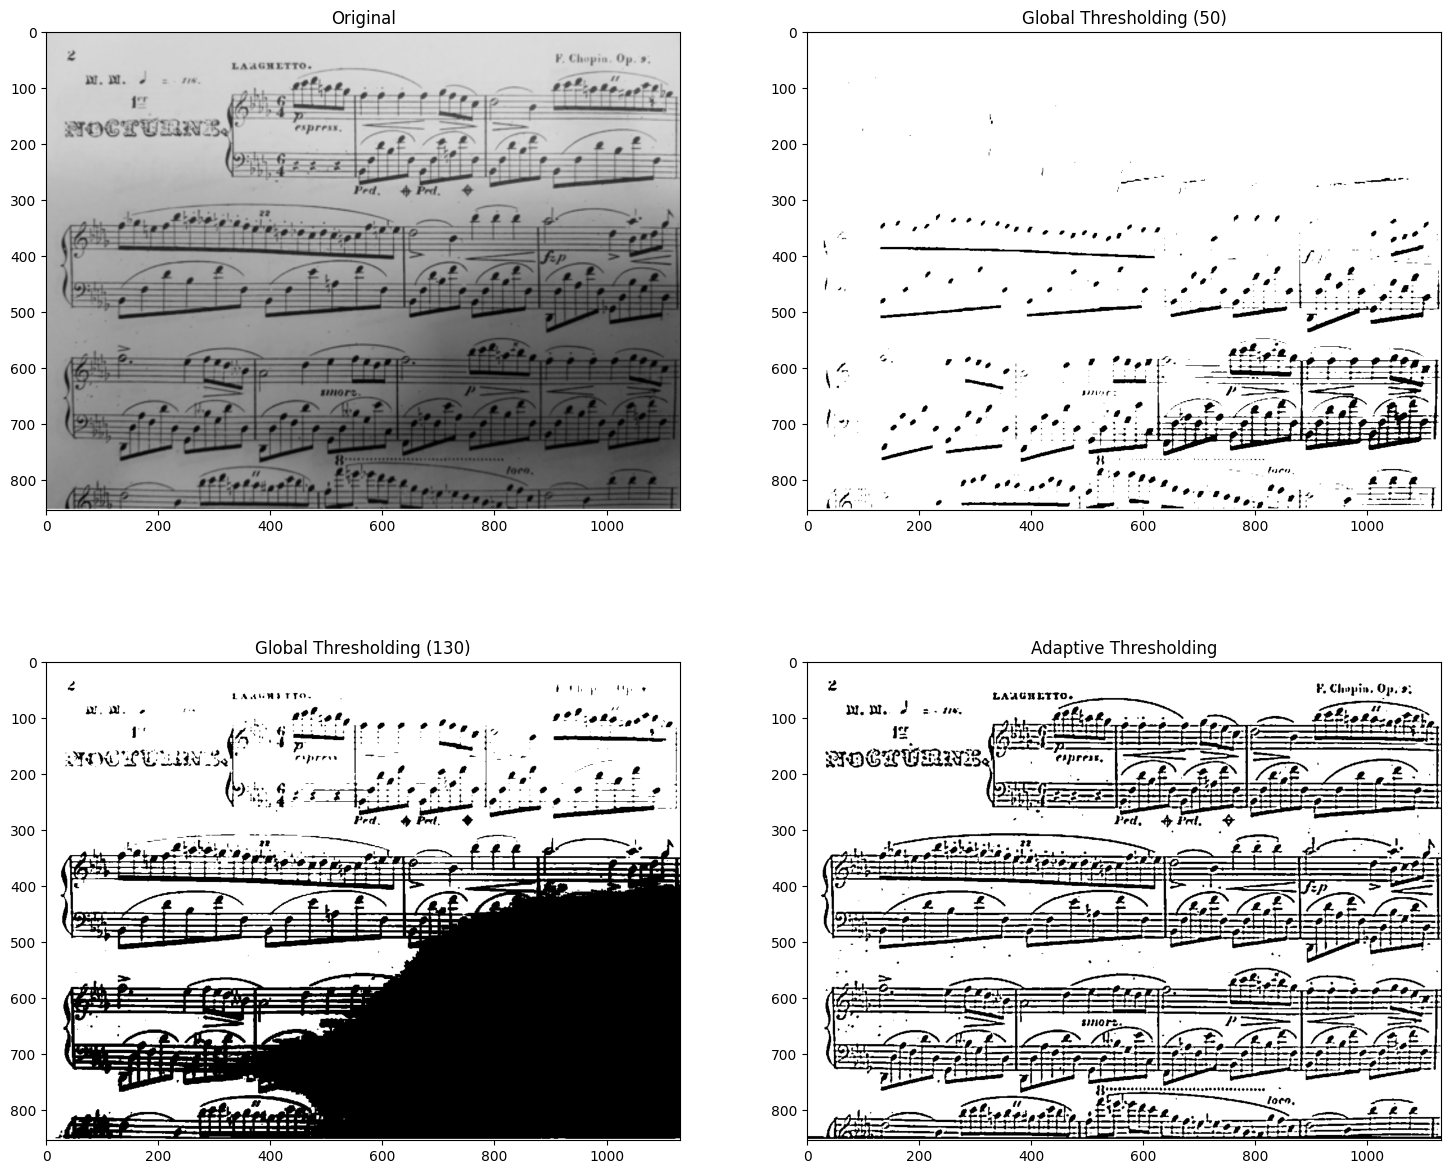

In [14]:
# Lendo a imagem original
img_read = cv2.imread("assets/Piano_Sheet_Music.png", cv2.IMREAD_GRAYSCALE)

# Aplicando o threshold global
retval, img_thresh_glb_1 = cv2.threshold(img_read, 50, 255, cv2.THRESH_BINARY)

# Aplicando o threshold global
retval, img_thresh_glb_2 = cv2.threshold(img_read, 130, 255, cv2.THRESH_BINARY)

# Aplicando o threshold adaptativo
img_thresh_adp = cv2.adaptiveThreshold(img_read, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 7)

# Mostrando as imagens
plt.figure(figsize=[18, 15])
plt.subplot(221); plt.imshow(img_read, cmap="gray"); plt.title("Original");
plt.subplot(222); plt.imshow(img_thresh_glb_1, cmap="gray"); plt.title("Global Thresholding (50)");
plt.subplot(223); plt.imshow(img_thresh_glb_2, cmap="gray"); plt.title("Global Thresholding (130)");
plt.subplot(224); plt.imshow(img_thresh_adp, cmap="gray"); plt.title("Adaptive Thresholding");

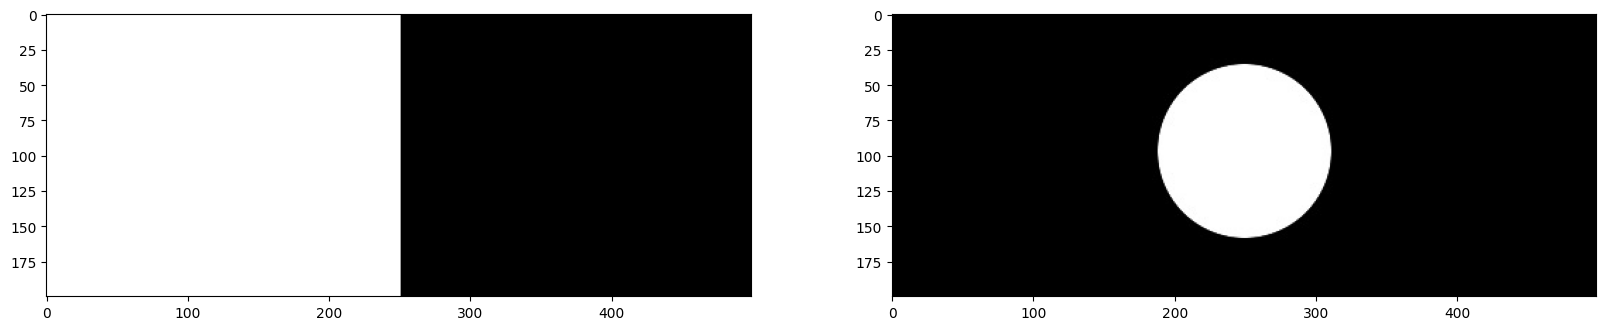

In [15]:
img_rec = cv2.imread("assets/rectangle.jpg", cv2.IMREAD_GRAYSCALE)
img_cir = cv2.imread("assets/circle.jpg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=[20, 5])
plt.subplot(121); plt.imshow(img_rec, cmap="gray");
plt.subplot(122); plt.imshow(img_cir, cmap="gray");

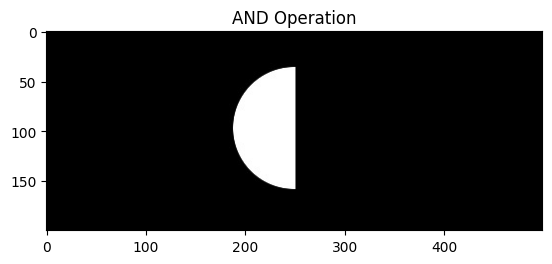

In [17]:
# Aplicando a operação AND bit a bit
result = cv2.bitwise_and(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray"); plt.title("AND Operation");

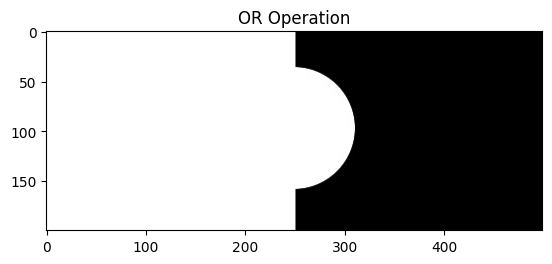

In [18]:
# Aplicando a operação OR bit a bit
result = cv2.bitwise_or(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray"); plt.title("OR Operation");

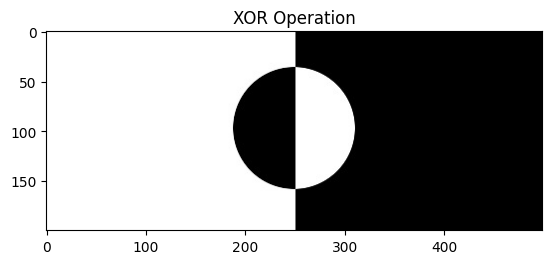

In [26]:
# Aplicando a operação XOR bit a bit
result = cv2.bitwise_xor(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray"); plt.title("XOR Operation");

(700, 700, 3)


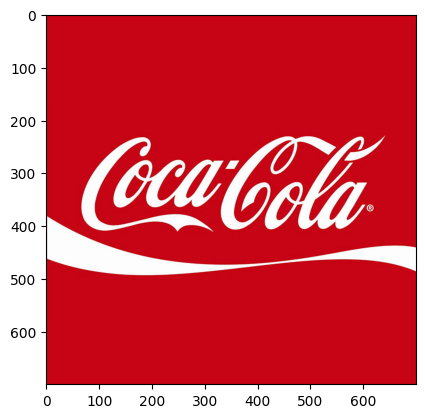

In [27]:
img_bgr = cv2.imread("assets/coca-cola-logo.png")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb);
print(img_rgb.shape)
logo_w = img_rgb.shape[0]
logo_h = img_rgb.shape[1]

(700, 700, 3)


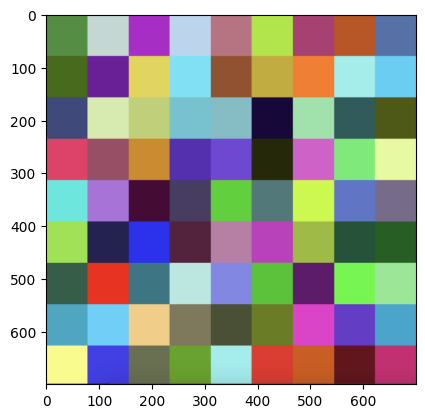

In [ ]:
# Redimensionando a imagem de fundo para ter a mesma largura do logo
img_backgroung_bgr = cv2.imread("assets/checkerboard_color.png")
img_backgroung_rgb = cv2.cvtColor(img_backgroung_bgr, cv2.COLOR_BGR2RGB)

aspect_ratio = logo_w / img_backgroung_rgb.shape[1]
dim = (logo_w, int(img_backgroung_rgb.shape[0] * aspect_ratio))

img_background_rgb = cv2.resize(img_backgroung_rgb, dim, interpolation=cv2.INTER_AREA)

plt.imshow(img_background_rgb);
print(img_background_rgb.shape);

(700, 700)


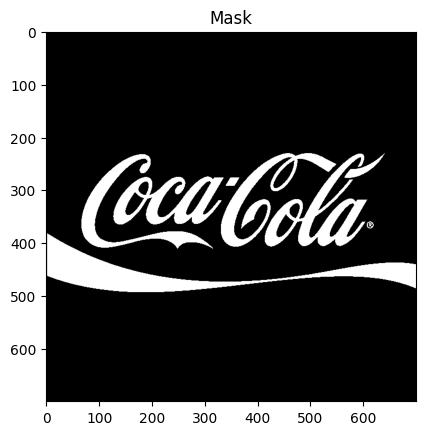

In [37]:
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Aplicando o threshold para criar uma máscara binária
retval, img_mask = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

plt.imshow(img_mask, cmap="gray"); plt.title("Mask");
print(img_mask.shape);

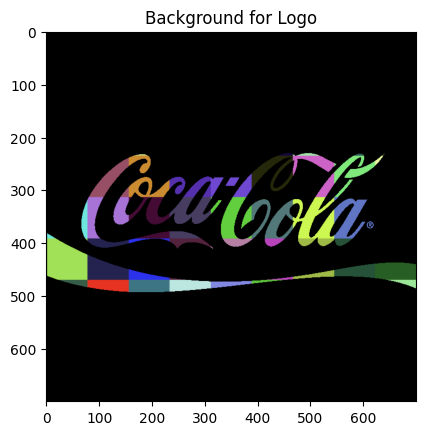

In [38]:
# Criando o background do logo usando a máscara
img_background = cv2.bitwise_and(img_background_rgb, img_background_rgb, mask=img_mask)
plt.imshow(img_background); plt.title("Background for Logo");